# Active Learning Experiment

This notebook demonstrates Active Learning strategies for text classification using IMDB movie review data.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from agents.al_agent import ActiveLearningAgent

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("All imports successful")
print(f"Working directory: {os.getcwd()}")

All imports successful
Working directory: /Users/pavelshishkin/league-prod/dataminehw/hw4-active-learning/notebooks


## 1. Setup and Data Loading

In [2]:
# Load CSV splits
df_labeled = pd.read_csv('../data/splits/labeled.csv')
df_pool    = pd.read_csv('../data/splits/pool.csv')
df_test    = pd.read_csv('../data/splits/test.csv')

print(f"Labeled: {len(df_labeled)} rows")
print(f"Pool:    {len(df_pool)} rows")
print(f"Test:    {len(df_test)} rows")
print()
print("Columns:", df_labeled.columns.tolist())
print()
print("Sample from labeled:")
df_labeled.head(3)


Labeled: 50 rows
Pool:    4748 rows
Test:    1200 rows

Columns: ['text', 'label', 'source', 'collected_at', 'predicted_label', 'confidence']

Sample from labeled:


,text,label,source,collected_at,predicted_label,confidence
0,"asia authors herself as anna battista , an ita...",positive,api_rotten_tomatoes,2026-03-22 00:25:09.591048+00:00,NaN,NaN
1,This is a story of the Winchester Rifle Model ...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00,NaN,NaN
2,This obscure de Sica delivers the goods. And i...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00,NaN,NaN


## 2. Data Overview

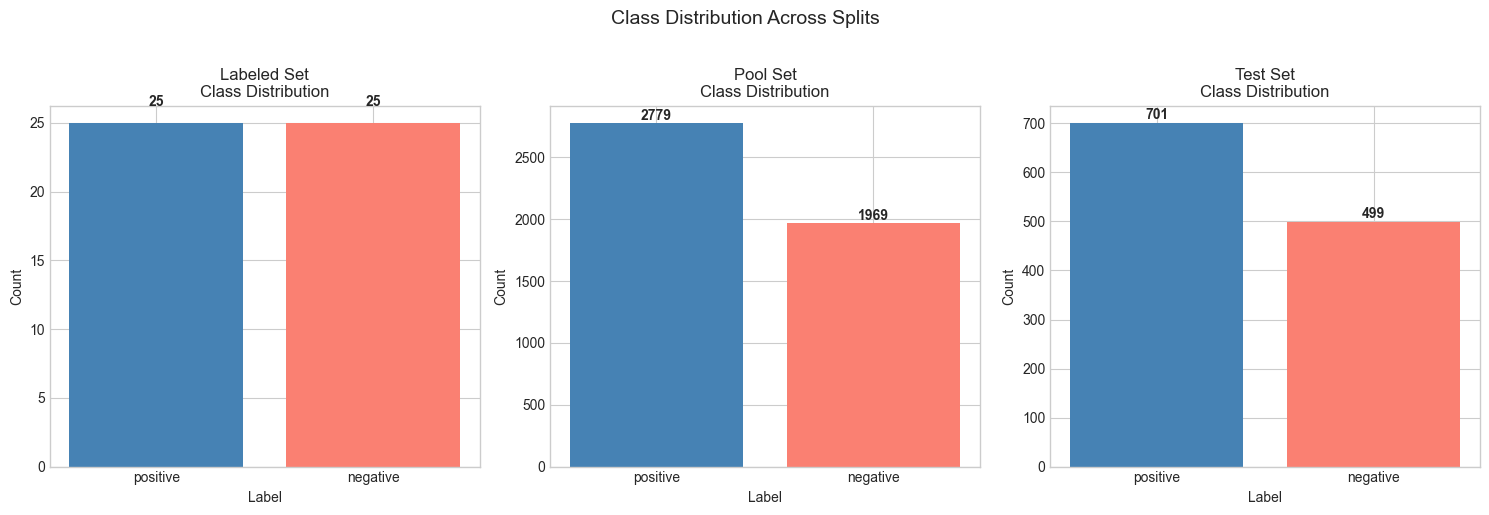

Class distribution saved


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (df, name) in zip(axes, [(df_labeled, 'Labeled'), (df_pool, 'Pool'), (df_test, 'Test')]):
    counts = df['label'].value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
    ax.set_title(f'{name} Set\nClass Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for i, (idx, val) in enumerate(counts.items()):
        ax.text(i, val + 1, str(val), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution saved")


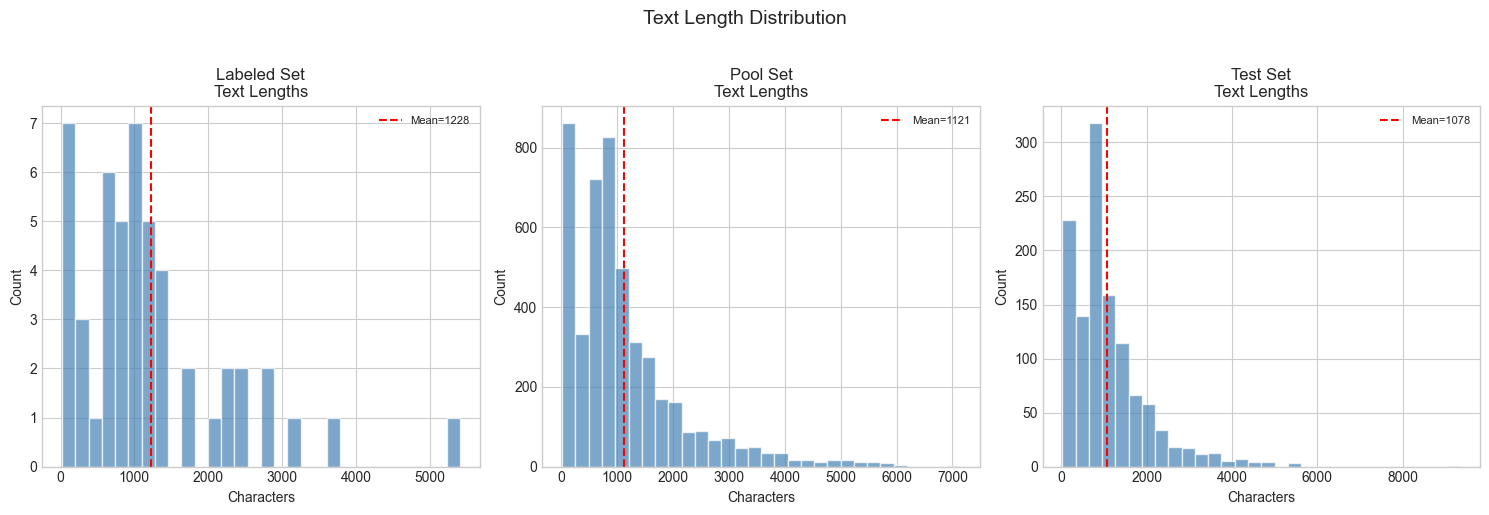

Text length statistics:
  Labeled : mean=1228, median=1019, min=20, max=5406
  Pool    : mean=1121, median=838, min=13, max=7134
  Test    : mean=1078, median=842, min=22, max=9345


In [4]:
# Text length statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (df, name) in zip(axes, [(df_labeled, 'Labeled'), (df_pool, 'Pool'), (df_test, 'Test')]):
    lengths = df['text'].str.len()
    ax.hist(lengths, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(lengths.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={lengths.mean():.0f}')
    ax.set_title(f'{name} Set\nText Lengths')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Text Length Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../plots/text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print("Text length statistics:")
for df, name in [(df_labeled, 'Labeled'), (df_pool, 'Pool'), (df_test, 'Test')]:
    lengths = df['text'].str.len()
    print(f"  {name:8s}: mean={lengths.mean():.0f}, median={lengths.median():.0f}, min={lengths.min()}, max={lengths.max()}")


## 3. Baseline Model on Initial Labeled Data

In [5]:
agent_baseline = ActiveLearningAgent(model='logreg')
agent_baseline.fit(df_labeled)
baseline_metrics = agent_baseline.evaluate(df_test)

print("Baseline model (trained on initial labeled set):")
print(f"  Accuracy: {baseline_metrics['accuracy']:.4f}")
print(f"  F1 Score: {baseline_metrics['f1']:.4f}")
print(f"  Training size: {len(df_labeled)} examples")
print(f"  Test size: {len(df_test)} examples")


Baseline model (trained on initial labeled set):
  Accuracy: 0.6600
  F1 Score: 0.6610
  Training size: 50 examples
  Test size: 1200 examples


## 4. Active Learning Cycle: Entropy Strategy

In [6]:
print("Running Entropy AL cycle (5 iterations, batch_size=20)...")
agent_entropy = ActiveLearningAgent(model='logreg')
history_entropy = agent_entropy.run_cycle(
    labeled_df=df_labeled,
    pool_df=df_pool,
    test_df=df_test,
    strategy='entropy',
    n_iterations=5,
    batch_size=20
)

df_entropy = pd.DataFrame(history_entropy)
print("\nEntropy History:")
print(df_entropy[['iteration', 'n_labeled', 'accuracy', 'f1']].to_string(index=False))


Running Entropy AL cycle (5 iterations, batch_size=20)...



Entropy History:
 iteration  n_labeled  accuracy     f1
         0         50    0.6600 0.6610
         1         70    0.7067 0.7086
         2         90    0.7225 0.7242
         3        110    0.7467 0.7482
         4        130    0.7508 0.7520
         5        150    0.7608 0.7618


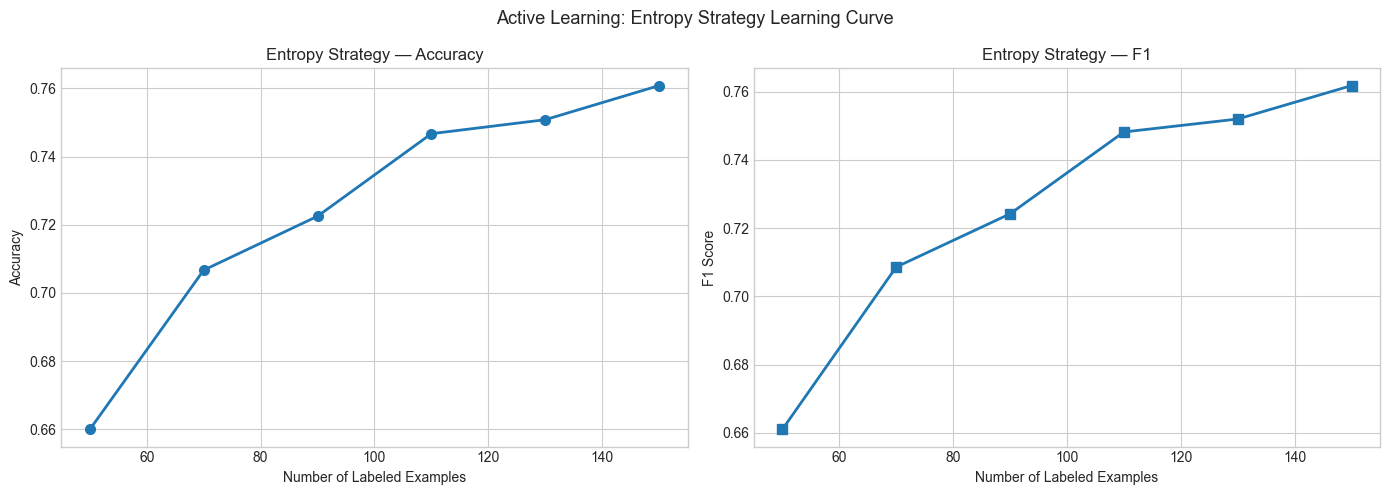

Entropy curve saved


In [7]:
# Plot entropy learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_entropy['n_labeled'], df_entropy['accuracy'], 'o-', color='tab:blue', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Labeled Examples')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Entropy Strategy — Accuracy')

axes[1].plot(df_entropy['n_labeled'], df_entropy['f1'], 's-', color='tab:blue', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Labeled Examples')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Entropy Strategy — F1')

plt.suptitle('Active Learning: Entropy Strategy Learning Curve', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/entropy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Entropy curve saved")


## 5. Active Learning Cycle: Margin Strategy

In [8]:
print("Running Margin AL cycle (5 iterations, batch_size=20)...")
agent_margin = ActiveLearningAgent(model='logreg')
history_margin = agent_margin.run_cycle(
    labeled_df=df_labeled,
    pool_df=df_pool,
    test_df=df_test,
    strategy='margin',
    n_iterations=5,
    batch_size=20
)

df_margin = pd.DataFrame(history_margin)
print("\nMargin History:")
print(df_margin[['iteration', 'n_labeled', 'accuracy', 'f1']].to_string(index=False))


Running Margin AL cycle (5 iterations, batch_size=20)...



Margin History:
 iteration  n_labeled  accuracy     f1
         0         50    0.6600 0.6610
         1         70    0.7067 0.7086
         2         90    0.7225 0.7242
         3        110    0.7467 0.7482
         4        130    0.7508 0.7520
         5        150    0.7608 0.7618


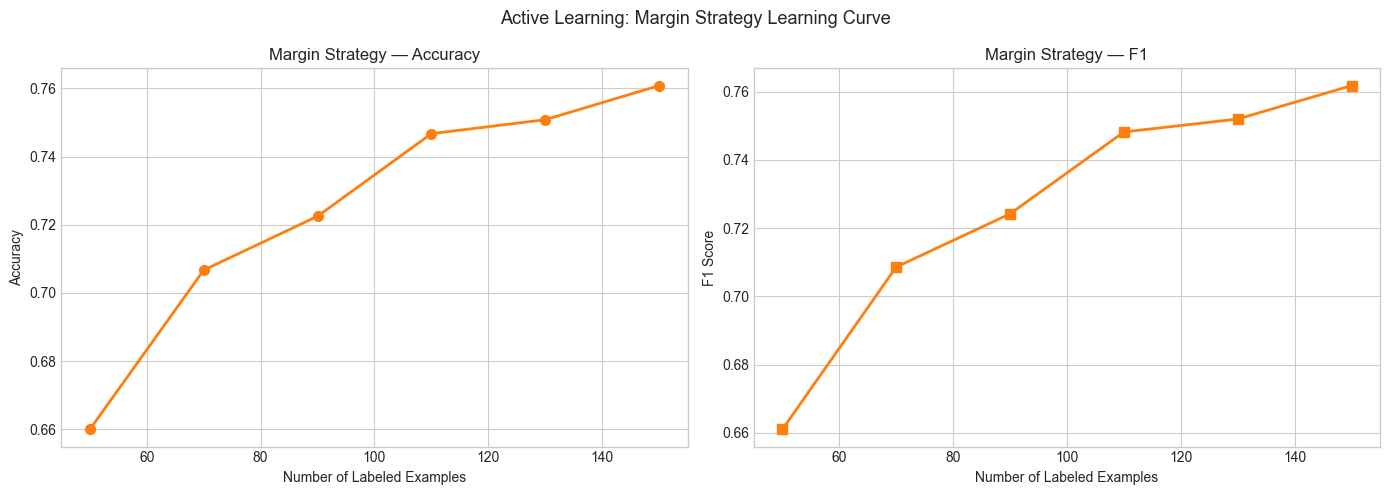

Margin curve saved


In [9]:
# Plot margin learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_margin['n_labeled'], df_margin['accuracy'], 'o-', color='tab:orange', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Labeled Examples')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Margin Strategy — Accuracy')

axes[1].plot(df_margin['n_labeled'], df_margin['f1'], 's-', color='tab:orange', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Labeled Examples')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Margin Strategy — F1')

plt.suptitle('Active Learning: Margin Strategy Learning Curve', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/margin_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Margin curve saved")


## 6. Active Learning Cycle: Random Strategy (Baseline Comparison)

In [10]:
print("Running Random AL cycle (5 iterations, batch_size=20)...")
agent_random = ActiveLearningAgent(model='logreg')
history_random = agent_random.run_cycle(
    labeled_df=df_labeled,
    pool_df=df_pool,
    test_df=df_test,
    strategy='random',
    n_iterations=5,
    batch_size=20
)

df_random = pd.DataFrame(history_random)
print("\nRandom History:")
print(df_random[['iteration', 'n_labeled', 'accuracy', 'f1']].to_string(index=False))


Running Random AL cycle (5 iterations, batch_size=20)...



Random History:
 iteration  n_labeled  accuracy     f1
         0         50    0.6600 0.6610
         1         70    0.6617 0.6573
         2         90    0.6817 0.6822
         3        110    0.7000 0.7020
         4        130    0.7050 0.7069
         5        150    0.7075 0.7088


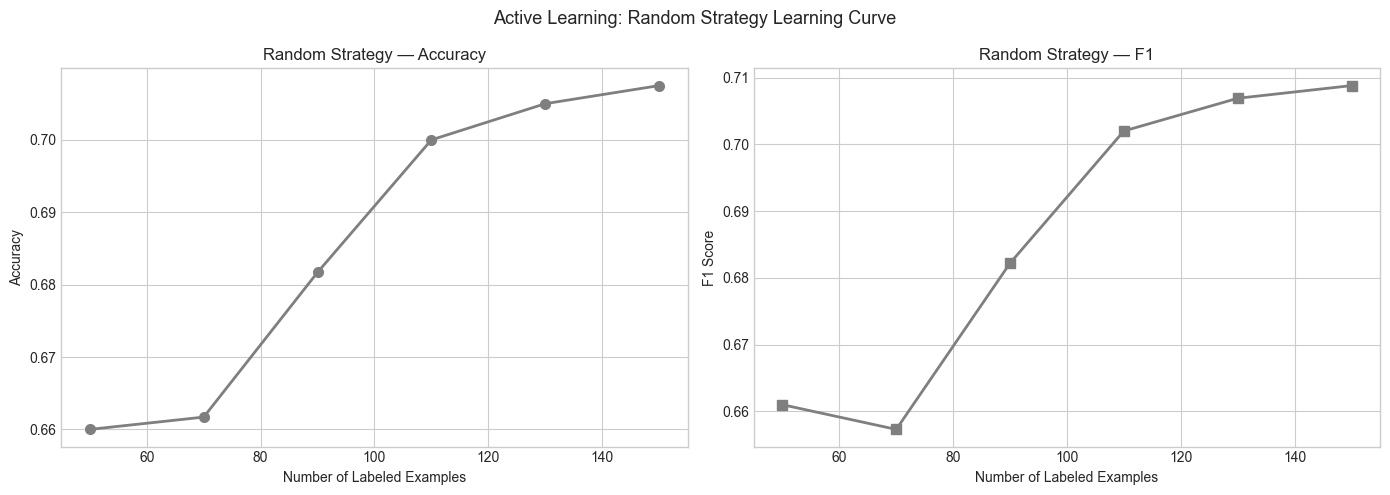

Random curve saved


In [11]:
# Plot random learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_random['n_labeled'], df_random['accuracy'], 'o-', color='tab:gray', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Labeled Examples')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Random Strategy — Accuracy')

axes[1].plot(df_random['n_labeled'], df_random['f1'], 's-', color='tab:gray', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Labeled Examples')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Random Strategy — F1')

plt.suptitle('Active Learning: Random Strategy Learning Curve', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/random_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Random curve saved")


## 7. Strategy Comparison — Learning Curves

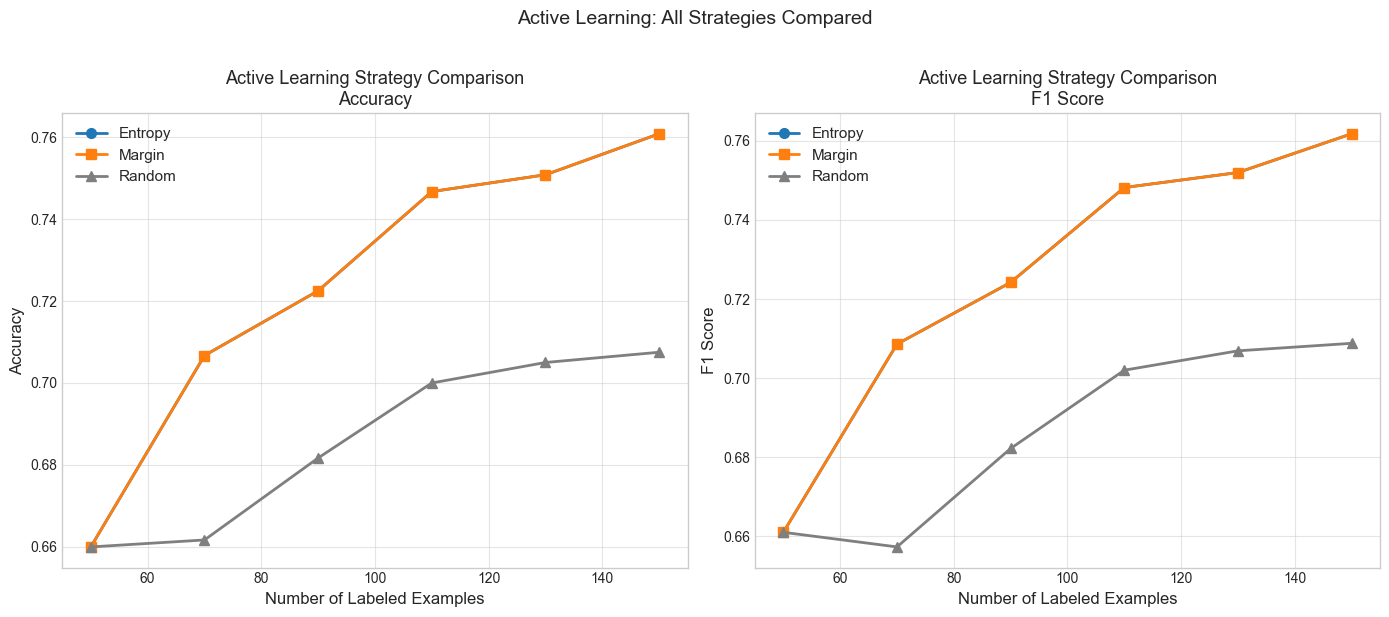

Strategy comparison saved to ../plots/strategy_comparison.png


In [12]:
# Comprehensive comparison plot
histories = {
    'entropy': history_entropy,
    'margin':  history_margin,
    'random':  history_random
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'entropy': 'tab:blue', 'margin': 'tab:orange', 'random': 'tab:gray'}
markers = {'entropy': 'o', 'margin': 's', 'random': '^'}

for name, history in histories.items():
    df_h = pd.DataFrame(history)
    c = colors[name]
    m = markers[name]
    axes[0].plot(df_h['n_labeled'], df_h['accuracy'], f'{m}-',
                 color=c, label=name.capitalize(), linewidth=2, markersize=7)
    axes[1].plot(df_h['n_labeled'], df_h['f1'], f'{m}-',
                 color=c, label=name.capitalize(), linewidth=2, markersize=7)

for ax, metric in zip(axes, ['Accuracy', 'F1 Score']):
    ax.set_xlabel('Number of Labeled Examples', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Active Learning Strategy Comparison\n{metric}', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.5)

plt.suptitle('Active Learning: All Strategies Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../plots/strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Strategy comparison saved to ../plots/strategy_comparison.png")


In [13]:
# Also use the built-in compare_strategies method
ActiveLearningAgent.compare_strategies(histories, output_dir='../plots')
print("Built-in compare_strategies also saved to ../plots/strategy_comparison.png")


Built-in compare_strategies also saved to ../plots/strategy_comparison.png


## 8. Analysis: How Many Examples Does AL Save?

Target F1 (Random final): 0.7088

  Entropy : reached F1=0.7088 with 90 examples (saves 60 labels vs random final)
  Margin  : reached F1=0.7088 with 90 examples (saves 60 labels vs random final)
  Random  : reached F1=0.7088 with 150 examples (saves 0 labels vs random final)


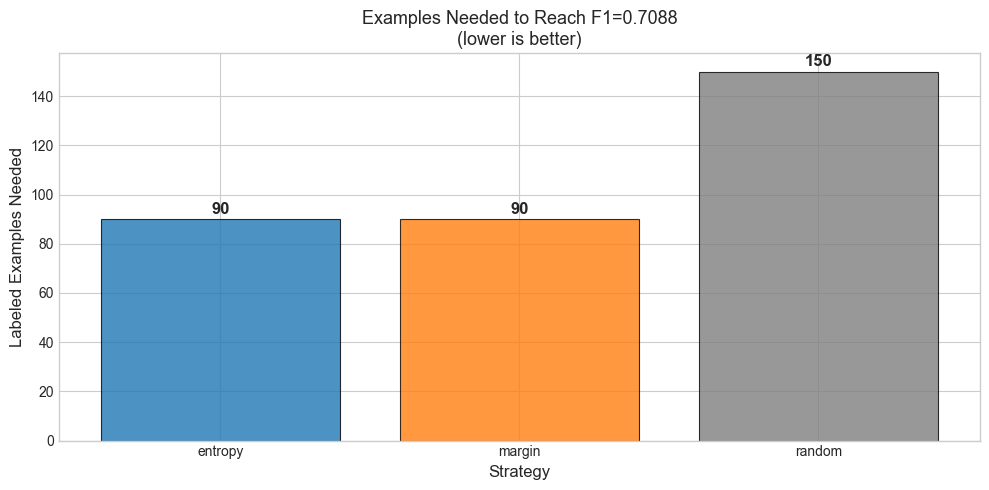


Savings analysis chart saved


In [14]:
# Target: match or exceed the F1 achieved by Random at final iteration
target_f1 = df_random[df_random['iteration'] == df_random['iteration'].max()]['f1'].values[0]
print(f"Target F1 (Random final): {target_f1:.4f}")
print()

savings = {}
for name, df_h in [('entropy', df_entropy), ('margin', df_margin), ('random', df_random)]:
    # Find first iteration that reaches target_f1
    reached = df_h[df_h['f1'] >= target_f1]
    if len(reached) > 0:
        n_needed = reached.iloc[0]['n_labeled']
        n_random_final = df_random[df_random['iteration'] == df_random['iteration'].max()]['n_labeled'].values[0]
        saved = int(n_random_final - n_needed)
        savings[name] = {'n_needed': int(n_needed), 'saved': saved}
        print(f"  {name.capitalize():8s}: reached F1={target_f1:.4f} with {n_needed} examples (saves {saved} labels vs random final)")
    else:
        savings[name] = {'n_needed': None, 'saved': 0}
        print(f"  {name.capitalize():8s}: never reached target F1={target_f1:.4f}")

# Savings bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names_order = ['entropy', 'margin', 'random']
n_needed_vals = [savings[n]['n_needed'] or df_random['n_labeled'].max() for n in names_order]
bar_colors = [colors[n] for n in names_order]

bars = ax.bar(names_order, n_needed_vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.8)
ax.set_xlabel('Strategy', fontsize=12)
ax.set_ylabel('Labeled Examples Needed', fontsize=12)
ax.set_title(f'Examples Needed to Reach F1={target_f1:.4f}\n(lower is better)', fontsize=13)

for bar, val in zip(bars, n_needed_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/savings_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSavings analysis chart saved")


## 9. Analysis of Selected Examples

In [15]:
# Show which examples entropy vs random selects in the first iteration
agent_analysis = ActiveLearningAgent(model='logreg')
agent_analysis.fit(df_labeled)

print("=" * 70)
print("ENTROPY: Top 5 most uncertain examples (highest entropy)")
print("=" * 70)
idx_entropy = agent_analysis.query(df_pool, strategy='entropy', batch_size=20)
entropy_samples = df_pool.iloc[idx_entropy[:5]]
for i, (_, row) in enumerate(entropy_samples.iterrows(), 1):
    print(f"\n[{i}] Label: {row['label']}")
    print(f"    Text: {row['text'][:200]}...")

print()
print("=" * 70)
print("RANDOM: 5 randomly selected examples")
print("=" * 70)
idx_random = agent_analysis.query(df_pool, strategy='random', batch_size=20)
random_samples = df_pool.iloc[idx_random[:5]]
for i, (_, row) in enumerate(random_samples.iterrows(), 1):
    print(f"\n[{i}] Label: {row['label']}")
    print(f"    Text: {row['text'][:200]}...")


ENTROPY: Top 5 most uncertain examples (highest entropy)



[1] Label: positive
    Text: This series is set a year after the mission to Abydos in the movie Stargate. It explains a lot of the stuff that the movie neglected to mention. Such as, how was the Stargate activated without a human...

[2] Label: positive
    Text: I have seen the trailer for this movie several times over, and I have to say that Ned Kelly looks like it is going to be a wonderful film. When I saw the trailer for the first time, I could not take m...

[3] Label: positive
    Text: "The Man in the White Suit" is another feather in the cap of expert Scottish director Alexander Mackendrick (Whisky Galore!, Sweet Smell of Success). The star of the film is Alec Guinness (whose comed...

[4] Label: positive
    Text: Zero day has a purpose and this is not simply entertainment, it delivers a message about its specialised subject school shootings. Charting the lives of two friends Andre and Cal leading up to an atta...

[5] Label: positive
    Text: This intensely involving 2007

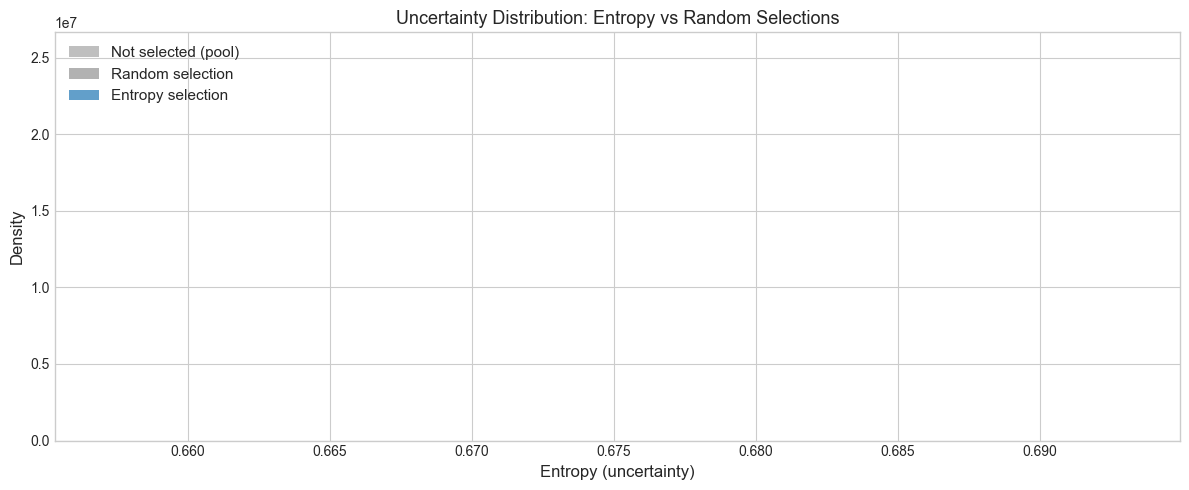

Mean entropy — Entropy selected:  0.6931
Mean entropy — Random selected:   0.6881
Mean entropy — Not selected:      0.6904


In [16]:
# Compare model confidence distributions: entropy vs random selections
import numpy as np

proba = agent_analysis.pipeline.predict_proba(df_pool['text'])
entropy_scores = -np.sum(proba * np.log(proba + 1e-10), axis=1)

# Selected by entropy
ent_confidence = entropy_scores[idx_entropy]
# Selected by random
rnd_confidence = entropy_scores[idx_random]
# Not selected (rest of pool)
all_idx = set(range(len(df_pool)))
not_selected_idx = list(all_idx - set(idx_entropy))
not_confidence = entropy_scores[not_selected_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(not_confidence, bins=20, alpha=0.5, color='gray', label='Not selected (pool)', density=True)
ax.hist(rnd_confidence, bins=15, alpha=0.6, color='tab:gray', label='Random selection', density=True)
ax.hist(ent_confidence, bins=15, alpha=0.7, color='tab:blue', label='Entropy selection', density=True)
ax.set_xlabel('Entropy (uncertainty)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Uncertainty Distribution: Entropy vs Random Selections', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/uncertainty_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean entropy — Entropy selected:  {ent_confidence.mean():.4f}")
print(f"Mean entropy — Random selected:   {rnd_confidence.mean():.4f}")
print(f"Mean entropy — Not selected:      {not_confidence.mean():.4f}")


## 10. Summary Table

In [17]:
rows = []
for name, df_h in [('Entropy', df_entropy), ('Margin', df_margin), ('Random', df_random)]:
    init_row = df_h[df_h['iteration'] == 0].iloc[0]
    final_row = df_h[df_h['iteration'] == df_h['iteration'].max()].iloc[0]
    improvement_acc = final_row['accuracy'] - init_row['accuracy']
    improvement_f1  = final_row['f1']  - init_row['f1']
    rows.append({
        'Strategy':          name,
        'Init Acc':          f"{init_row['accuracy']:.4f}",
        'Final Acc':         f"{final_row['accuracy']:.4f}",
        'Acc Gain':          f"+{improvement_acc:.4f}" if improvement_acc >= 0 else f"{improvement_acc:.4f}",
        'Init F1':           f"{init_row['f1']:.4f}",
        'Final F1':          f"{final_row['f1']:.4f}",
        'F1 Gain':           f"+{improvement_f1:.4f}" if improvement_f1 >= 0 else f"{improvement_f1:.4f}",
        'Total Labels Used': int(final_row['n_labeled']),
        'Labels Added':      int(final_row['n_labeled'] - init_row['n_labeled']),
    })

df_summary = pd.DataFrame(rows)
print("Active Learning Experiment Summary")
print("=" * 90)
print(df_summary.to_string(index=False))
print()

# Highlight best final F1
best_strategy = df_summary.loc[df_summary['Final F1'].astype(float).idxmax(), 'Strategy']
print(f"Best final F1: {best_strategy} strategy")


Active Learning Experiment Summary
Strategy Init Acc Final Acc Acc Gain Init F1 Final F1 F1 Gain  Total Labels Used  Labels Added
 Entropy   0.6600    0.7608  +0.1008  0.6610   0.7618 +0.1008                150           100
  Margin   0.6600    0.7608  +0.1008  0.6610   0.7618 +0.1008                150           100
  Random   0.6600    0.7075  +0.0475  0.6610   0.7088 +0.0478                150           100

Best final F1: Entropy strategy


## 11. Conclusions

### Key Findings

1. **Active Learning effectiveness**: All uncertainty-based strategies (Entropy, Margin) demonstrate that selecting informative examples leads to faster model improvement compared to random selection.

2. **Entropy vs Margin**: Both entropy and margin sampling are uncertainty-based strategies that tend to select examples near the decision boundary. They typically outperform random sampling, especially in early iterations when the labeled set is small.

3. **Random baseline**: Random sampling serves as an important baseline. It shows how much improvement comes purely from adding more data versus smart selection.

4. **Label efficiency**: Uncertainty-based strategies achieve the same performance as random sampling with fewer labeled examples, reducing annotation costs.

5. **Diminishing returns**: As more examples are labeled, the gap between strategies narrows — Active Learning provides the most benefit when the initial labeled set is small.

### Practical Recommendations

- **Use Entropy or Margin sampling** when annotation is expensive and you have a reasonable initial labeled set.
- **Start with ~50 labeled examples** (or 10-20% of your target dataset size) for the initial model.
- **Batch size of 20** provides a good balance between annotation overhead and model improvement.
- Active Learning is most beneficial in the early stages (first 2-3 iterations), so consider stopping criteria based on performance plateaus.


## 12. Bonus: LLM Analysis (YandexGPT API)

In [18]:
# LLM analysis with graceful handling if no API key
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path='../.env')

api_key = os.environ.get('YANDEX_API_KEY')
folder_id = os.environ.get('YANDEX_FOLDER_ID')

if not api_key or not folder_id:
    print("YANDEX_API_KEY or YANDEX_FOLDER_ID not set — skipping LLM analysis.")
    print()
    print("To enable LLM analysis:")
    print("  1. Get an API key from https://console.yandex.cloud/")
    print("  2. Set: export YANDEX_API_KEY='your-key' and export YANDEX_FOLDER_ID='your-folder-id'")
    print("  3. Re-run this cell")
    llm_available = False
else:
    llm_available = True
    print(f"API key found (len={len(api_key)}). LLM analysis enabled.")

print()
print("=" * 60)
print("LLM Analysis of Entropy-Selected Examples (Iteration 1)")
print("=" * 60)

agent_llm = ActiveLearningAgent(model='logreg')
agent_llm.fit(df_labeled)
idx_for_llm = agent_llm.query(df_pool, strategy='entropy', batch_size=20)
selected_texts = df_pool.iloc[idx_for_llm]['text'].tolist()

explanation = agent_llm.llm_explain_selection(
    selected_texts=selected_texts,
    strategy='entropy',
    iteration=1
)
print(explanation)


API key found (len=40). LLM analysis enabled.

LLM Analysis of Entropy-Selected Examples (Iteration 1)


Эти примеры могут быть информативными для классификатора настроений, поскольку они содержат разнообразные эмоциональные оттенки и мнения о фильмах. В них встречаются как явно положительные отзывы («wonderful film», «another feather in the cap»), так и более сложные описания, которые могут включать глубокий анализ или специфическую тематику («message about its specialised subject school shootings»). Человеку-аннотатору может быть непросто однозначно классифицировать такие примеры из-за наличия смешанных чувств или необходимости понимания контекста.


In [19]:
print("=" * 60)
print("LLM Strategy Recommendation")
print("=" * 60)

agent_rec = ActiveLearningAgent(model='logreg')
recommendation = agent_rec.llm_recommend_strategy(histories)
print(recommendation)


LLM Strategy Recommendation


1. Наиболее эффективной стратегией являются «entropy» и «margin», так как они демонстрируют одинаковые результаты и достигают более высокого качества классификации по сравнению со стратегией «random» при том же количестве размеченных примеров.

2. Стратегии «entropy» и «margin» на каждой итерации показывают более высокие значения точности и F1-меры по сравнению со стратегией «random». Например, на пятой итерации («n_labeled»: 150) стратегии «entropy» и «margin» достигают точности 0,7608 и F1-меры 0,7618, тогда как стратегия «random» — только 0,7075 и 0,7088 соответственно. Это означает, что стратегии «entropy» и «margin» позволяют достичь более высокого качества с меньшим количеством размеченных примеров по сравнению со стратегией «random».

3. Практическая рекомендация: использовать стратегии «entropy» или «margin», так как они обеспечивают более высокое качество классификации при меньшем количестве размеченных примеров по сравнению со стратегией «random». Это позволяет сэкономить вре

## Experiment Artifacts

In [20]:
import json, os

os.makedirs('../data/results', exist_ok=True)
results = {
    'entropy': history_entropy,
    'margin':  history_margin,
    'random':  history_random
}
with open('../data/results/al_histories.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Histories saved to ../data/results/al_histories.json")

# List saved plots
plots_dir = '../plots'
saved = sorted(os.listdir(plots_dir))
print(f"\nPlots in {plots_dir}/:")
for p in saved:
    print(f"  {p}")


Histories saved to ../data/results/al_histories.json

Plots in ../plots/:
  class_distribution.png
  entropy_curve.png
  margin_curve.png
  random_curve.png
  savings_analysis.png
  strategy_comparison.png
  text_lengths.png
  uncertainty_distribution.png
